# Data Exploration & Analysis

Three heterogeneous text sources selected to stress-test extraction and summarisation pipelines:

- **Amazon Product Reviews** (~74k) — short, opinionated, sentiment-heavy
- **Customer Support Tickets** (~29.8k) — template-heavy, noisy, issue-focused
- **CNN/DailyMail News** (~11.5k) — long-form, entity-dense, with gold-standard summaries

In [1]:
import os
import sys

# Set working directory to project root
os.chdir('/Users/jessepassmore/Desktop/Programming_Pizazz/nlp_fun/nlp_parsing_gcp')
sys.path.insert(0, os.getcwd())

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.data.loader import load_reviews, load_support_tickets, load_news
from src.data.preprocessing import preprocess_documents, get_text_stats, tokenize_words

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print(f'Working directory: {os.getcwd()}')
print('All imports loaded!')

Working directory: /Users/jessepassmore/Desktop/Programming_Pizazz/nlp_fun/nlp_parsing_gcp
All imports loaded!


## 1. Load All Datasets

Each loader normalises its source into a universal `Document` format.

In [2]:
# Load each source separately so we can analyze per-source characteristics
reviews = load_reviews(max_docs=5000)
tickets = load_support_tickets(max_docs=5000)

# CNN/DailyMail downloads on first run (~300MB). Caches after that.
news = load_news(max_docs=2000)

print(f'Reviews: {len(reviews)}')
print(f'Tickets: {len(tickets)}')
print(f'News:    {len(news)}')

/Users/jessepassmore/Desktop/Programming_Pizazz/nlp_fun/nlp_parsing_gcp/src/data/loader.py:52: DtypeWarning: Columns (0: name, 1: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, encoding="utf-8", on_bad_lines="skip")


Reviews: 5000
Tickets: 5000
News:    2000


In [3]:
# Run preprocessing and compute text stats for EDA
all_docs = reviews + tickets + news
all_docs = preprocess_documents(all_docs, compute_stats=True)

# Flatten into a DataFrame — pandas is great for exploratory slicing
rows = []
for doc in all_docs:
    row = {
        'id': doc.id,
        'source_type': doc.source_type,
        'text': doc.text,
        'created_at': doc.created_at,
        **doc.metadata.get('text_stats', {}),
    }
    rows.append(row)

df = pd.DataFrame(rows)
df.head()

,id,source_type,text,created_at,char_count,word_count,sentence_count,avg_word_length,avg_sentence_length,stopword_ratio
0,review_0,review,I order 3 of them and one of the item is bad q...,2017-03-02T00:00:00.000Z,139,31,2,3.451613,15.5,0.516129
1,review_1,review,Bulk is always the less expensive way to go fo...,2016-08-31T00:00:00.000Z,67,13,1,4.230769,13.0,0.384615
2,review_2,review,Well they are not Duracell but for the price i...,2016-12-06T00:00:00.000Z,56,12,1,3.666667,12.0,0.666667
3,review_3,review,Seem to work as well as name brand batteries a...,2016-03-28T00:00:00.000Z,67,14,1,3.857143,14.0,0.357143
4,review_4,review,These batteries are very long lasting the pric...,2017-04-22T00:00:00.000Z,57,10,1,4.700000,10.0,0.500000


## 2. Corpus Overview

Document counts, length distributions, and sentence complexity per source.

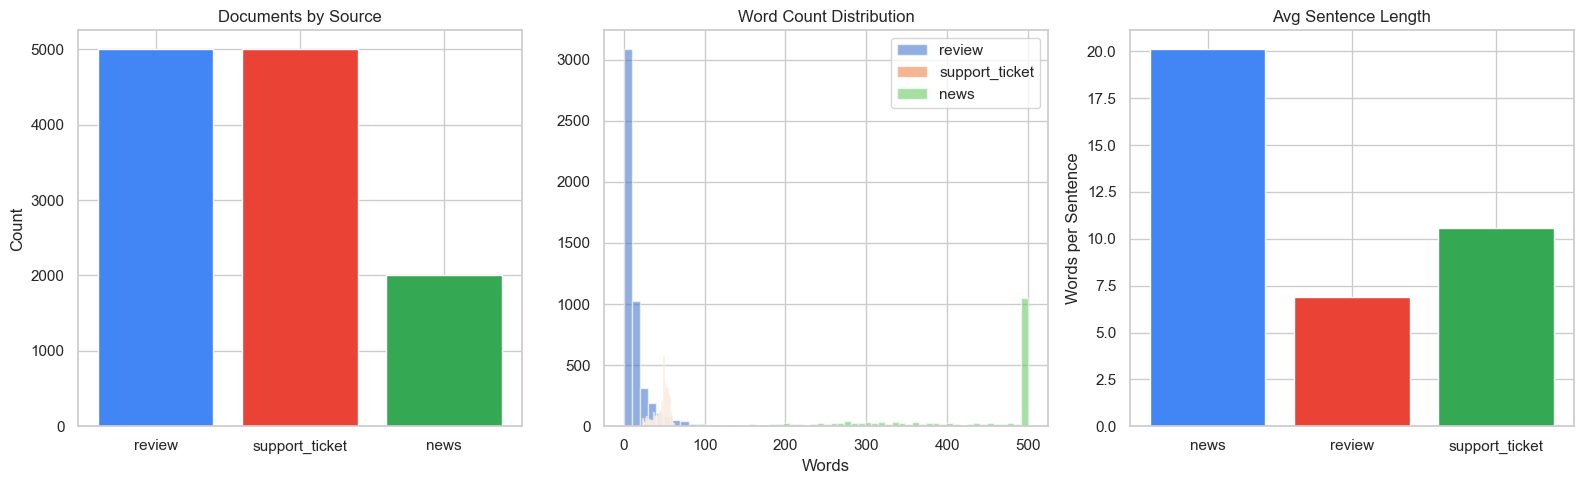

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# How many documents per source?
source_counts = df['source_type'].value_counts()
axes[0].bar(source_counts.index, source_counts.values, color=['#4285F4', '#EA4335', '#34A853'])
axes[0].set_title('Documents by Source')
axes[0].set_ylabel('Count')

# How long are they? (word count distribution)
for src in df['source_type'].unique():
    subset = df[df['source_type'] == src]
    axes[1].hist(subset['word_count'].clip(upper=500), bins=50, alpha=0.6, label=src)
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Words')
axes[1].legend()

# How complex are the sentences?
avg_sent = df.groupby('source_type')['avg_sentence_length'].mean()
axes[2].bar(avg_sent.index, avg_sent.values, color=['#4285F4', '#EA4335', '#34A853'])
axes[2].set_title('Avg Sentence Length')
axes[2].set_ylabel('Words per Sentence')

plt.tight_layout()
plt.show()

In [5]:
# The numbers behind the pictures
stats_summary = df.groupby('source_type')[['char_count', 'word_count', 'sentence_count', 'avg_sentence_length', 'stopword_ratio']].describe()
stats_summary.round(2)

char_count                                                   \
                    count     mean      std    min     25%     50%     75%   
source_type                                                                  
news               2000.0  3364.37  1922.31  464.0  1856.5  2893.5  4507.0   
review             5000.0    74.10   130.78    1.0    16.0    35.0    79.0   
support_ticket     5000.0   252.77    47.00   47.0   233.0   264.0   285.0   

                        word_count          ... avg_sentence_length         \
                    max      count    mean  ...                 75%    max   
source_type                                 ...                              
news            11648.0     2000.0  589.08  ...               22.46  35.40   
review           4875.0     5000.0   13.72  ...                9.00  64.00   
support_ticket    358.0     5000.0   46.93  ...               12.25  19.67   

               stopword_ratio                                            
                        count  mean   std   min   25%   50%   75%   max  
source_type                                                              
news                   2000.0  0.41  0.05  0.09  0.38  0.41  0.44  0.53  
review                 5000.0  0.32  0.22  0.00  0.00  0.38  0.50  1.00  
support_ticket         5000.0  0.49  0.06  0.15  0.46  0.50  0.53  0.68  

[3 rows x 40 columns]

## 3. Per-Source Deep Dive

### 3a. Amazon Reviews

Rating distribution and top brands. Reviews are short, sentiment-heavy, and entity-sparse.

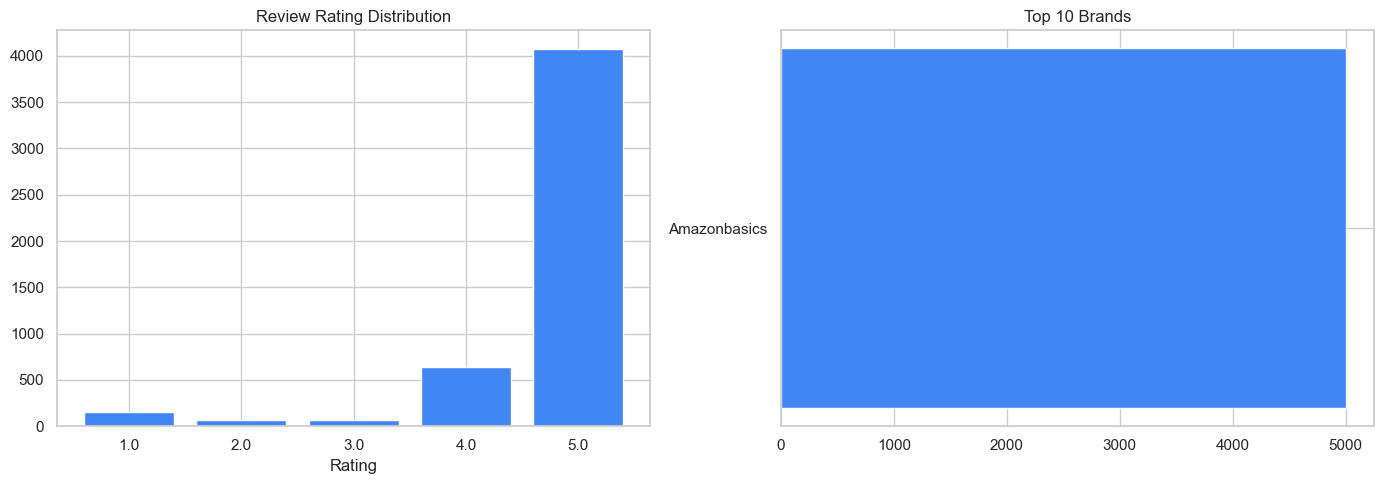

In [6]:
review_meta = pd.DataFrame([d.metadata for d in reviews])
review_meta['text_length'] = [len(d.text) for d in reviews]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Star ratings — are we dealing with mostly happy or mostly angry customers?
if 'rating' in review_meta.columns:
    rating_counts = review_meta['rating'].value_counts().sort_index()
    axes[0].bar(rating_counts.index.astype(str), rating_counts.values, color='#4285F4')
    axes[0].set_title('Review Rating Distribution')
    axes[0].set_xlabel('Rating')

# Which brands show up the most?
if 'brand' in review_meta.columns:
    top_brands = review_meta['brand'].value_counts().head(10)
    axes[1].barh(top_brands.index, top_brands.values, color='#4285F4')
    axes[1].set_title('Top 10 Brands')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 3b. Support Tickets

Ticket type and priority distributions. Text is noisy with `{placeholder}` tags, but metadata is rich (type, priority, product, resolution).

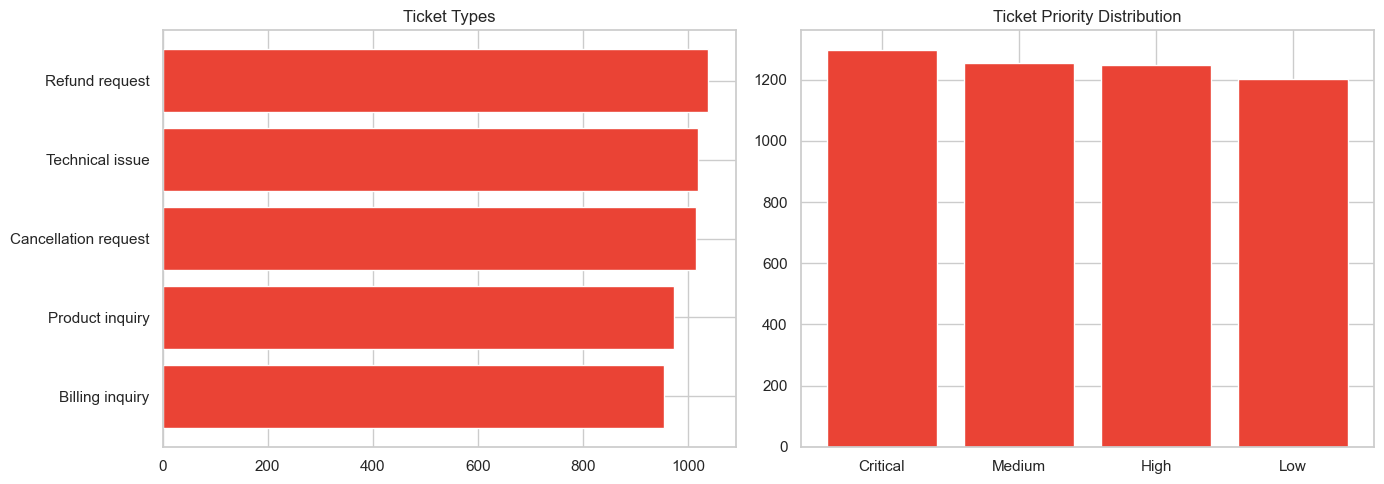

In [7]:
ticket_meta = pd.DataFrame([d.metadata for d in tickets])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# What kinds of tickets are people filing?
if 'type' in ticket_meta.columns:
    type_counts = ticket_meta['type'].value_counts().head(8)
    axes[0].barh(type_counts.index, type_counts.values, color='#EA4335')
    axes[0].set_title('Ticket Types')
    axes[0].invert_yaxis()

# Priority distribution — are most tickets critical or low?
if 'priority' in ticket_meta.columns:
    prio_counts = ticket_meta['priority'].value_counts()
    axes[1].bar(prio_counts.index, prio_counts.values, color='#EA4335')
    axes[1].set_title('Ticket Priority Distribution')

plt.tight_layout()
plt.show()

## 4. Cross-Source Vocabulary Analysis

Top-20 words per source (stopwords removed). Vocabulary differences inform extraction pipeline requirements: reviews skew toward product/quality terms, tickets toward issue/action terms, news toward named entities.

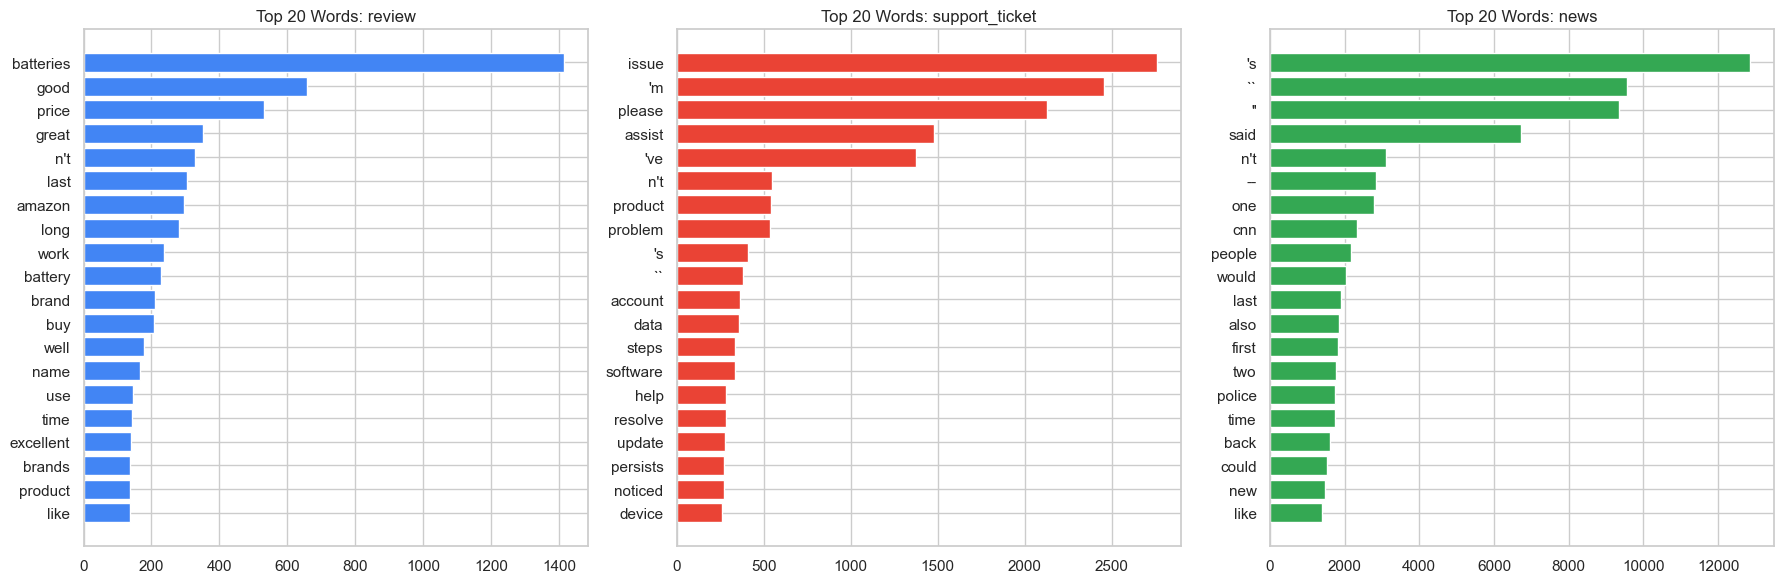

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (src, docs) in enumerate([
    ('review', reviews[:2000]),
    ('support_ticket', tickets[:2000]),
    ('news', news[:2000]),
]):
    all_words = []
    for doc in docs:
        all_words.extend(tokenize_words(doc.text, remove_stopwords=True))

    top_20 = Counter(all_words).most_common(20)
    words, counts = zip(*top_20)

    colors = ['#4285F4', '#EA4335', '#34A853']
    axes[i].barh(list(words), list(counts), color=colors[i])
    axes[i].set_title(f'Top 20 Words: {src}')
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Sample Documents

Representative sample from each source: text quality, metadata, formatting.

In [9]:
import textwrap
import json

for src, docs in [('Review', reviews), ('Ticket', tickets), ('News', news)]:
    print(f'\n{"="*80}')
    print(f' {src} Sample')
    print(f'{"="*80}')
    doc = docs[0]
    print(f'ID: {doc.id}')
    print(f'Text: {textwrap.shorten(doc.text, 300)}')
    print(f'Metadata: {json.dumps({k: v for k, v in doc.metadata.items() if k != "text_stats"}, indent=2, default=str)}')


 Review Sample
ID: review_0
Text: I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.
Metadata: {
  "product_name": "AmazonBasics AAA Performance Alkaline Batteries (36 Count)",
  "brand": "Amazonbasics",
  "rating": 3.0,
  "title": "... 3 of them and one of the item is bad quality. Is missing backup spring so I have ...",
  "categories": "AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care"
}

 Ticket Sample
ID: ticket_1
Text: I'm having an issue with the . Please assist. Your billing zip code is: 71701. We appreciate that you have requested a website address. Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.
Metadata

## 6. Key Takeaways

- **Reviews**: short-to-medium, sentiment-heavy, product/brand entities. Strong candidate for sentiment analysis.
- **Support tickets**: short, template-heavy with noise, but rich metadata (priority, product, resolution). Preprocessing earns its keep here.
- **News articles**: long-form, entity-dense (people, orgs, locations, dates), gold-standard human summaries for evaluation.
- The three sources differ in vocabulary, structure, and length: exactly the variation needed to validate pipeline generalisation.